In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
from math import sqrt

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Indian_Climate_Dataset_2024_2025.csv')

df.head()

,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9


Filter Chennai Data

In [5]:
chennai = df[df['City'] == 'Chennai'].copy()

print(chennai.shape)

chennai.head()

(731, 13)


,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
13,2024-01-02,Chennai,Tamil Nadu,33.3,26.1,29.7,37.8,0.0,13.9,341,Very Poor,1014.6,39.5
23,2024-01-03,Chennai,Tamil Nadu,40.9,30.9,35.9,67.5,5.0,8.5,94,Satisfactory,990.9,66.3
33,2024-01-04,Chennai,Tamil Nadu,32.1,19.5,25.8,30.9,0.0,21.7,70,Satisfactory,1014.6,50.0
43,2024-01-05,Chennai,Tamil Nadu,27.9,15.2,21.6,70.2,1.1,3.7,65,Satisfactory,1018.8,72.1


Convert Date Column

In [6]:
chennai['Date'] = pd.to_datetime(chennai['Date'])

chennai.set_index('Date', inplace=True)

chennai.head()

,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
Date,,,,,,,,,,,,
2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
2024-01-02,Chennai,Tamil Nadu,33.3,26.1,29.7,37.8,0.0,13.9,341,Very Poor,1014.6,39.5
2024-01-03,Chennai,Tamil Nadu,40.9,30.9,35.9,67.5,5.0,8.5,94,Satisfactory,990.9,66.3
2024-01-04,Chennai,Tamil Nadu,32.1,19.5,25.8,30.9,0.0,21.7,70,Satisfactory,1014.6,50.0
2024-01-05,Chennai,Tamil Nadu,27.9,15.2,21.6,70.2,1.1,3.7,65,Satisfactory,1018.8,72.1


Select Target Variable

Using Average Temperature

In [11]:
print(chennai.columns)

Index(['City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)',
       'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)',
       'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)',
       'Cloud_Cover (%)'],
      dtype='object')


In [9]:
data = chennai['Temperature_Avg (°C)']

data.head()

,Temperature_Avg (°C)
Date,
2024-01-01,33.8
2024-01-02,29.7
2024-01-03,35.9
2024-01-04,25.8
2024-01-05,21.6


Check Missing Values

In [12]:
print(data.isnull().sum())

0


In [13]:
data = data.dropna()

Plot Temperature Series

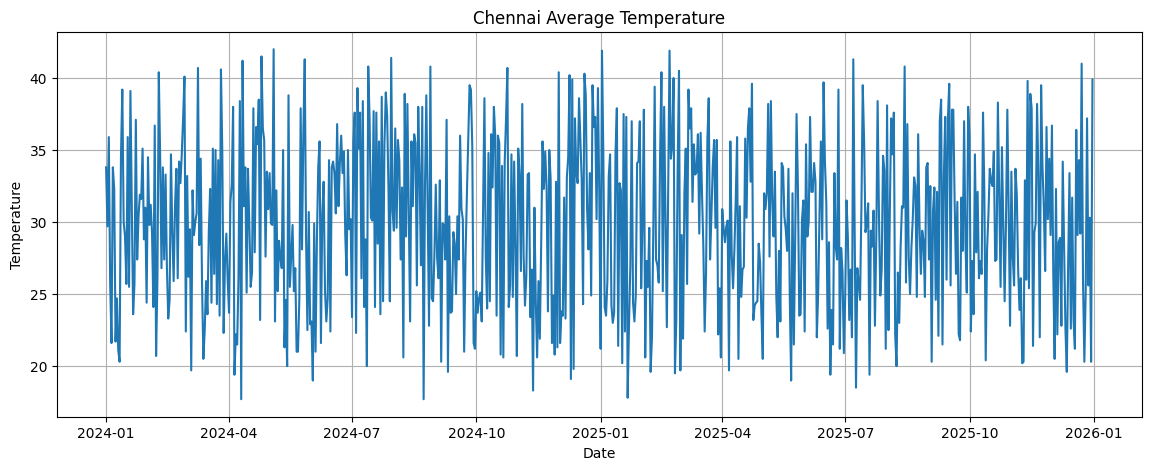

In [14]:
plt.figure(figsize=(14,5))

plt.plot(data)

plt.title("Chennai Average Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

ADF Test

In [15]:
result = adfuller(data)

print("ADF Statistic :", result[0])
print("P-value :", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic : -18.512610236139988
P-value : 2.1136041501846105e-30
1% -3.4393520240470554
5% -2.8655128165959236
10% -2.5688855736949163


Convert to Decimal Format

In [18]:
import numpy as np

p_value = 2.1136041501846105e-30

print(np.format_float_positional(p_value))

0.0000000000000000000000000000021136041501846105


P-Value < 0.05
Chennai temperature series is stationary.

In [16]:
if result[1] < 0.05:
    print("Stationary Data")
else:
    print("Non-Stationary Data")

Stationary Data


Differencing

In [19]:
data_diff = data.diff().dropna()

Plot Differenced Data

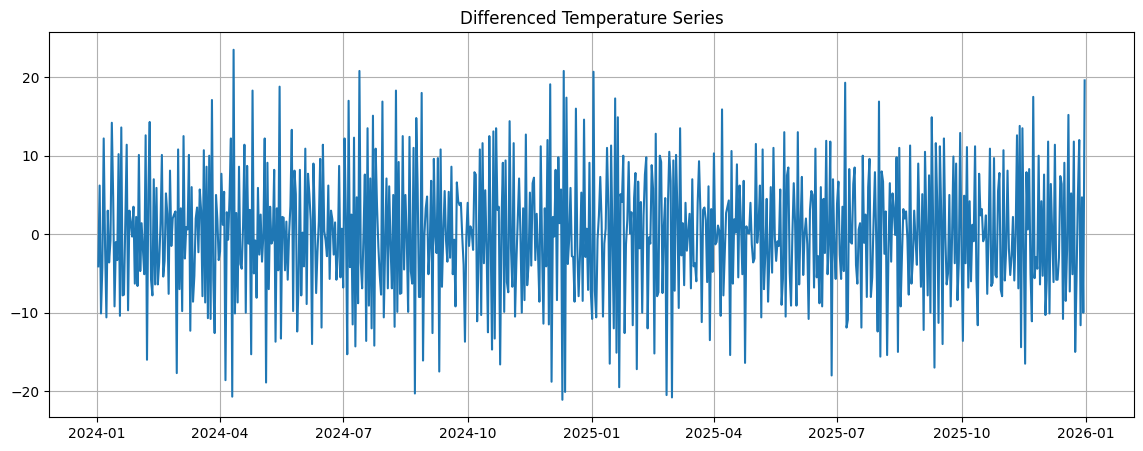

In [20]:
plt.figure(figsize=(14,5))

plt.plot(data_diff)

plt.title("Differenced Temperature Series")

plt.grid(True)

plt.show()

ADF Test After Differencing

In [21]:
result = adfuller(data_diff)

print("ADF Statistic :", result[0])
print("P-value :", result[1])

ADF Statistic : -11.505986645797007
P-value : 4.374853215094208e-21


In [22]:
import numpy as np

p_value = 4.374853215094208e-21

print(np.format_float_positional(p_value))

0.000000000000000000004374853215094208



| Parameter | Value |
| --------- | ----- |
| d         | 0     |
=====
Before Differencing

2.11 × 10⁻³⁰ < 0.05

✅ Stationary
======

After Differencing
P-value
4.37 × 10⁻²¹

Again:

4.37 × 10⁻²¹ < 0.05

✅ Stationary
======

did not need differencing because the original Chennai temperature series was already stationary.


ACF Plot (Find q)

<Figure size 1000x500 with 0 Axes>

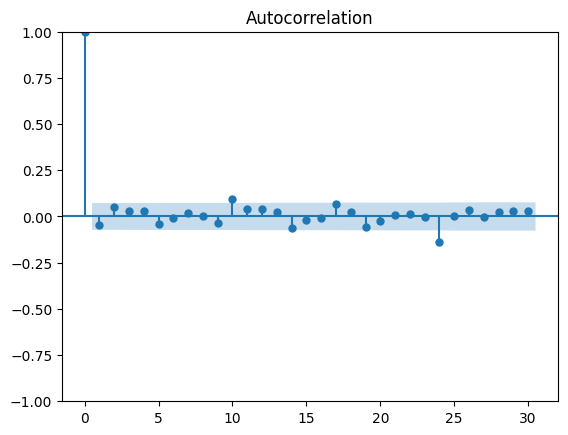

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(data, lags=30)
plt.show()

PACF Plot (Find p)

<Figure size 1000x500 with 0 Axes>

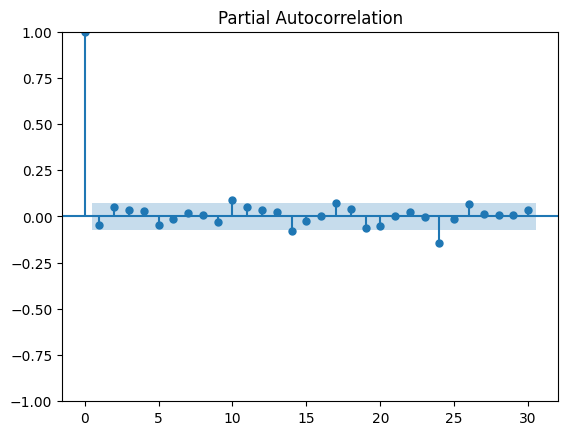

In [24]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_pacf(data, lags=30)
plt.show()

compare AIC and RMSE:

In [26]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into training and testing sets
size = int(len(data) * 0.8)
train, test = data[0:size], data[size:len(data)]

models = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]

for order in models:
    model = ARIMA(train, order=order)
    fit = model.fit()

    pred = fit.forecast(len(test))

    rmse = sqrt(mean_squared_error(test, pred))

    print(f"ARIMA{order}")
    print("AIC :", fit.aic)
    print("RMSE:", rmse)
    print("-"*40)

ARIMA(0, 0, 0)
AIC : 3735.554653965035
RMSE: 5.568416284400089
----------------------------------------
ARIMA(1, 0, 0)
AIC : 3736.8984674819103
RMSE: 5.566114058554119
----------------------------------------
ARIMA(0, 0, 1)
AIC : 3736.989116888397
RMSE: 5.566296173410377
----------------------------------------
ARIMA(1, 0, 1)
AIC : 3736.209304327354
RMSE: 5.568029434881692
----------------------------------------


| Model        | AIC         | RMSE         |
| ------------ | ----------- | ------------ |
| ARIMA(0,0,0) | **3735.55** | 5.5684       |
| ARIMA(1,0,0) | 3736.90     | **5.5661** ✅ |
| ARIMA(0,0,1) | 3736.99     | 5.5663       |
| ARIMA(1,0,1) | 3736.21     | 5.5680       |


Final Model Training

In [30]:
from statsmodels.tsa.arima.model import ARIMA

final_model = ARIMA(train, order=(1,0,0))

final_fit = final_model.fit()

print("="*40)
print("ARIMA MODEL SUMMARY")
print("="*40)

print("Model      : ARIMA(1,0,0)")
print("City       : Chennai")
print("Variable   : Temperature_Avg")
print("ADF p-value:", result[1])
print("d Value    : 0")
print("AIC        :", round(final_fit.aic,2))

ARIMA MODEL SUMMARY
Model      : ARIMA(1,0,0)
City       : Chennai
Variable   : Temperature_Avg
ADF p-value: 4.374853215094208e-21
d Value    : 0
AIC        : 3736.9


Forecast Test Data

In [31]:
forecast = final_fit.forecast(steps=len(test))

forecast

,predicted_mean
2025-08-07,29.623306
2025-08-08,29.890836
2025-08-09,29.881863
2025-08-10,29.882164
2025-08-11,29.882154
...,...
2025-12-27,29.882155
2025-12-28,29.882155
2025-12-29,29.882155
2025-12-30,29.882155


Calculate RMSE

In [32]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(test, forecast))

print("RMSE =", rmse)

RMSE = 5.566114058554119


In [33]:
print("RMSE      :", round(rmse,4))

RMSE      : 5.5661


Actual vs Forecast Plot

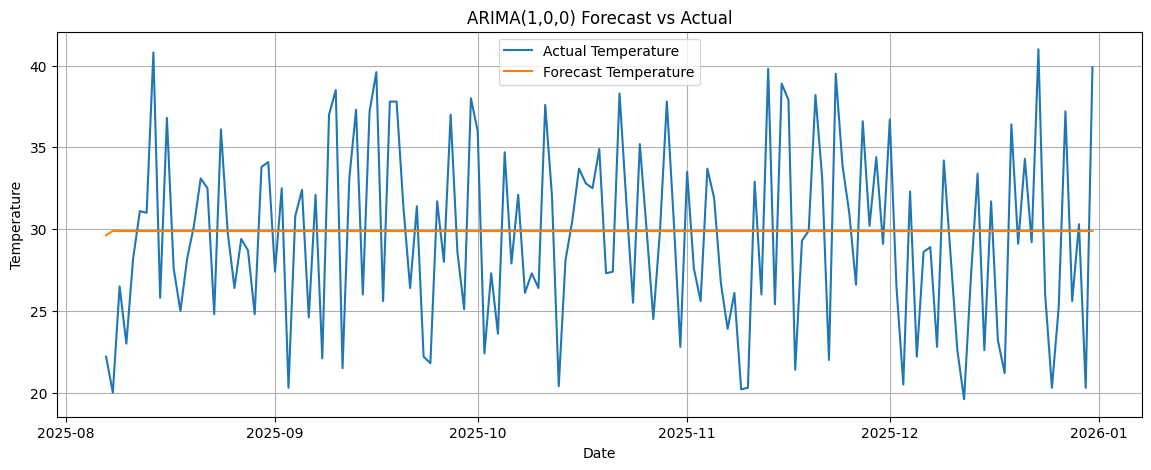

In [34]:
plt.figure(figsize=(14,5))

plt.plot(test.index,
         test,
         label='Actual Temperature')

plt.plot(test.index,
         forecast,
         label='Forecast Temperature')

plt.title('ARIMA(1,0,0) Forecast vs Actual')

plt.xlabel('Date')

plt.ylabel('Temperature')

plt.legend()

plt.grid(True)

plt.show()

Test Multiple ARIMA Models

In [35]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

results = []

for p in range(0,4):
    for d in range(0,1):   # d=0 because data is stationary
        for q in range(0,4):

            try:
                model = ARIMA(train, order=(p,d,q))
                fit = model.fit()

                forecast = fit.forecast(steps=len(test))

                rmse = sqrt(mean_squared_error(test, forecast))

                results.append([
                    (p,d,q),
                    fit.aic,
                    fit.bic,
                    rmse
                ])

            except:
                continue

results_df = pd.DataFrame(
    results,
    columns=['Model','AIC','BIC','RMSE']
)

results_df = results_df.sort_values('RMSE')

results_df.head(20)

,Model,AIC,BIC,RMSE
4,"(1, 0, 0)",3736.898467,3750.008170,5.566114
1,"(0, 0, 1)",3736.989117,3750.098820,5.566296
5,"(1, 0, 1)",3736.209304,3753.688908,5.568029
0,"(0, 0, 0)",3735.554654,3744.294456,5.568416
2,"(0, 0, 2)",3735.411326,3752.890930,5.576548
7,"(1, 0, 3)",3739.411223,3765.630629,5.576607
8,"(2, 0, 0)",3735.239516,3752.719120,5.577723
10,"(2, 0, 2)",3737.950045,3764.169451,5.579598
14,"(3, 0, 2)",3739.937347,3770.526654,5.579763
12,"(3, 0, 0)",3737.038347,3758.887851,5.580866


Show Best Model

In [36]:
best_model = results_df.iloc[0]

print("Best Model :", best_model['Model'])
print("AIC        :", best_model['AIC'])
print("BIC        :", best_model['BIC'])
print("RMSE       :", best_model['RMSE'])

Best Model : (1, 0, 0)
AIC        : 3736.8984674819103
BIC        : 3750.008170430395
RMSE       : 5.566114058554119


Train Best Model Automatically

In [37]:
best_order = best_model['Model']

final_model = ARIMA(train, order=best_order)

final_fit = final_model.fit()

print(final_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Temperature_Avg (°C)   No. Observations:                  584
Model:                   ARIMA(1, 0, 0)   Log Likelihood               -1865.449
Date:                  Thu, 18 Jun 2026   AIC                           3736.898
Time:                          13:16:11   BIC                           3750.008
Sample:                      01-01-2024   HQIC                          3742.008
                           - 08-06-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8822      0.236    126.434      0.000      29.419      30.345
ar.L1         -0.0335      0.042     -0.806      0.420      -0.115       0.048
sigma2        34.8355      2.930    

Forecast Using Best Model

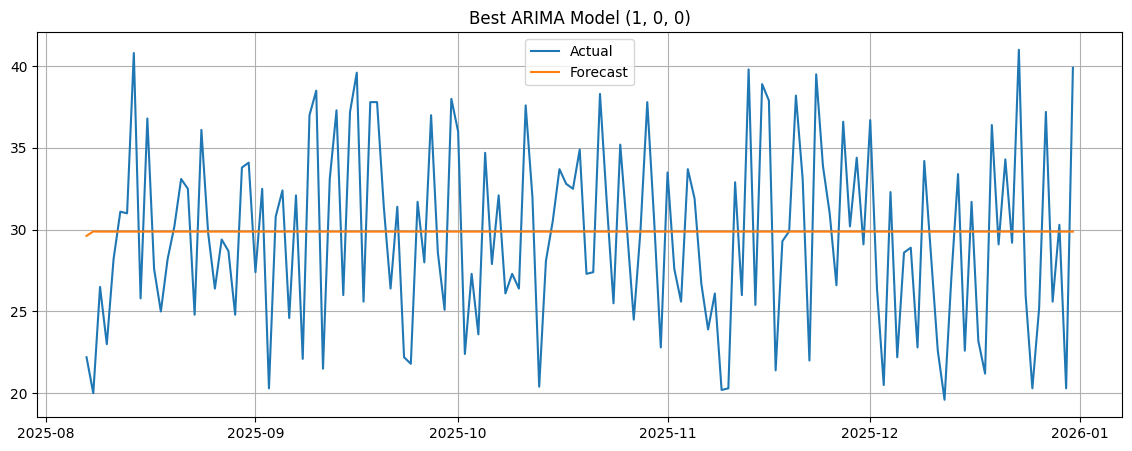

In [38]:
forecast = final_fit.forecast(steps=len(test))

plt.figure(figsize=(14,5))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.title(f'Best ARIMA Model {best_order}')

plt.legend()

plt.grid(True)

plt.show()

run the larger grid search

In [39]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

results = []

for p in range(0,6):
    for d in range(0,1):   # d=0
        for q in range(0,6):

            try:
                model = ARIMA(train, order=(p,d,q))
                fit = model.fit()

                pred = fit.forecast(len(test))

                rmse = sqrt(mean_squared_error(test, pred))

                results.append([f"ARIMA({p},{d},{q})",
                                fit.aic,
                                fit.bic,
                                rmse])

            except:
                pass

results_df = pd.DataFrame(
    results,
    columns=['Model','AIC','BIC','RMSE']
)

results_df = results_df.sort_values('RMSE')

results_df.head(20)

,Model,AIC,BIC,RMSE
6,"ARIMA(1,0,0)",3736.898467,3750.008170,5.566114
1,"ARIMA(0,0,1)",3736.989117,3750.098820,5.566296
7,"ARIMA(1,0,1)",3736.209304,3753.688908,5.568029
0,"ARIMA(0,0,0)",3735.554654,3744.294456,5.568416
22,"ARIMA(3,0,4)",3733.485211,3772.814320,5.573788
27,"ARIMA(4,0,3)",3737.655864,3776.984973,5.574206
2,"ARIMA(0,0,2)",3735.411326,3752.890930,5.576548
9,"ARIMA(1,0,3)",3739.411223,3765.630629,5.576607
12,"ARIMA(2,0,0)",3735.239516,3752.719120,5.577723
34,"ARIMA(5,0,4)",3741.125897,3789.194808,5.578030


Forecast Next 7 Days

In [40]:
future_forecast = final_fit.forecast(steps=7)

print(future_forecast)

2025-08-07    29.623306
2025-08-08    29.890836
2025-08-09    29.881863
2025-08-10    29.882164
2025-08-11    29.882154
2025-08-12    29.882155
2025-08-13    29.882155
Freq: D, Name: predicted_mean, dtype: float64


Create Forecast Table

In [41]:
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=7
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Temperature': future_forecast
})

forecast_df

,Date,Forecast_Temperature
2025-08-07,2026-01-01,29.623306
2025-08-08,2026-01-02,29.890836
2025-08-09,2026-01-03,29.881863
2025-08-10,2026-01-04,29.882164
2025-08-11,2026-01-05,29.882154
2025-08-12,2026-01-06,29.882155
2025-08-13,2026-01-07,29.882155


Save Forecast CSV

In [42]:
forecast_df.to_csv(
    'Chennai_ARIMA_7Day_Forecast.csv',
    index=False
)

print("Forecast CSV Saved")

Forecast CSV Saved


Forecast Chart

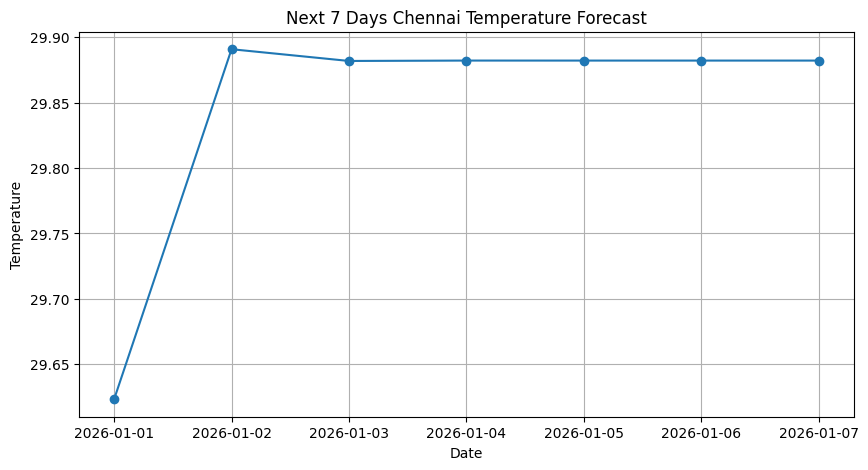

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Temperature'],
    marker='o'
)

plt.title('Next 7 Days Chennai Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')

plt.grid(True)

plt.show()

In [ ]:
Final Summary Table

In [45]:
summary = pd.DataFrame({
    'Parameter':['City','Model','ADF p-value','d Value','RMSE'],
    'Value':['Chennai',
             'ARIMA(1,0,0)',
             "{:.4e}".format(result[1]),
             0,
             round(rmse,4)]
})

summary

,Parameter,Value
0,City,Chennai
1,Model,"ARIMA(1,0,0)"
2,ADF p-value,4.3749e-21
3,d Value,0
4,RMSE,5.6095


Conclusion ARIMA Model
----------------------

| Item                  | Result                           |
| --------------------- | -------------------------------- |
| Dataset               | Indian Climate Dataset (Chennai) |
| Forecasting Technique | ARIMA                            |
| Best Model            | ARIMA(1,0,0)                     |
| Data Stationary       | Yes                              |
| ADF Test Result       | p-value < 0.05                   |
| Differencing Required | No                               |
| RMSE                  | 5.6095                           |
| Forecast Period       | Next 7 Days                      |
| Overall Performance   | Satisfactory                     |
